# <img src="assets/logo_infnetv1.png" alt="Infnet logo" height="45"/> Projeto de Disciplina - Processamento de linguagem natural


### Aluno: 

- Lauro Barbosa <a href="https://github.com/LMRocha/D5_fundamentos_ml_scikitlearning"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/></a>


### Descrição do projeto:
O dataset utiliza de 2225 artigos da BBC categorizadas  business, entertainment, politics, sport or tech

## Importação as bibliotecas

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import re
from dotenv import load_dotenv
import os
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi
import seaborn as sns
import warnings
import nltk
import spacy
import csv
import string
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')
load_dotenv()
SEED=42

## Geração dos diretórios e download do dataset

In [99]:
# Inicializar a API do Kaggle
api = KaggleApi()
api.authenticate()

# Criar o diretório se não existir
data_path = 'data'
os.makedirs(data_path, exist_ok=True)

# Baixar os dados do Kaggle
api.dataset_download_files('hgultekin/bbcnewsarchive', path=data_path, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive


## Declaração de funções

### Funções de preparação de texto

In [100]:
def tokenize(text):
    return text.split()

def normalize(text):   
    return text.lower()

def clean_text(text):
    return re.sub(r'[^a-z\s]', '', text)

def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(t) for t in tokens]

def stemmize(tokens):
    stemmizer = PorterStemmer();
    return [stemmizer.stem(t) for t in tokens]

def apply_pos_tagging(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    filtered_words = [
        token.lemma_
        for token in doc
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']
            and not token.is_stop
    ]

    return " ".join(filtered_words)

def preprocess_text(text, is_lemmatize: bool, is_stemmize: bool, is_pos_tagging: bool):
    text = normalize(text)
    text = clean_text(text)
    stop_words = set(stopwords.words('english'))
    tokens = tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    
    if is_lemmatize:
        tokens = lemmatize(tokens)
        return ' '.join(tokens)
    elif is_stemmize:
        tokens = stemmize(tokens)
        return ' '.join(tokens)
    elif is_pos_tagging:
        apply_pos_tagging(text)

def plot_word_cloud(processed_text):
    text = " ".join(processed_text)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

def plot_bar_frequencia(processed_text):
    all_words = " ".join(processed_text).split()
    word_freq = Counter(all_words)
    common_words = word_freq.most_common(10)
    words = [word[0] for word in common_words]
    counts = [word[1] for word in common_words]

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title("Top 10 Words")
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.show()

### Funções de vetorização

In [101]:
def vetorizer_tfidf(docs):
    return TfidfVectorizer().fit_transform(docs)

def vetorizer_bow(docs):
    return CountVectorizer().fit_transform(docs)

def vetorizer_bow_ngrams(docs,range1, range2):
    return CountVectorizer(ngram_range=(range1,range2)).fit_transform(docs)

def vetorizer_word2vec(sentences, vector_size=5, window=2, min_count=1):
    model = Word2Vec(sentences, vector_size=vector_size, window=window, min_count=min_count)
    doc_vectors = []
    for doc in sentences:
        word_vectors = [model.wv[word] for word in doc if word in model.wv]
        if word_vectors:
            doc_vector = np.mean(word_vectors, axis=0)
        else:
            # If no words in vocabulary, return zero vector
            doc_vector = np.zeros(vector_size)
        doc_vectors.append(doc_vector)
    return np.array(doc_vectors)


### Funções de busca

In [102]:
def buscar(query, vectorizer, X_matrix, y_labels, original_texts, top_k=5):
    query_proc = preprocess_text(query, is_lemmatize=True, is_stemmize=False, is_pos_tagging=False)
    q_vec = vectorizer.transform([query_proc])
    scores = cosine_similarity(q_vec, X_matrix).flatten()
    indices = scores.argsort()[::-1][:top_k]
    print(f"Query: '{query}'\n")
    for i, idx in enumerate(indices, 1):
        print(f"{i}. Similaridade: {scores[idx]:.4f} | Categoria: {y_labels[idx]}")
        print(f"   Excerto: {original_texts[idx][:150]}...\n")
    return query_proc,q_vec,scores,indices

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def buscar_w2v(query, w2v_model, doc_vectors, y_labels, original_texts, top_k=5):
    query_proc = preprocess_text(query, is_lemmatize=True, is_stemmize=False, is_pos_tagging=False)
    tokens = query_proc.split()
    word_vecs = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if word_vecs:
        q_vec = np.mean(word_vecs, axis=0)
    else:
        q_vec = np.zeros(w2v_model.wv.vector_size)
    scores = cosine_similarity([q_vec], doc_vectors).flatten()
    indices = scores.argsort()[::-1][:top_k]
    print(f"Query: '{query}'\n")
    for i, idx in enumerate(indices, 1):
        print(f"{i}. Similaridade: {scores[idx]:.4f} | Categoria: {y_labels[idx]}")
        print(f"   Excerto: {original_texts[idx][:150]}...\n")
    return query_proc,q_vec,scores,indices


def plot_category_distribution(y_labels, indices, top_k=5):
    categories = [y_labels[i] for i in indices[:top_k]]
    cat_counts = Counter(categories)
    plt.figure(figsize=(8, 6))
    plt.pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("pastel"))
    plt.title(f"Distribuição de Categorias nos Top-{top_k} Resultados")
    plt.show()

def plot_pca_projection(doc_vectors, indices, query_vec=None, top_k=5):
    if query_vec is not None:
        all_vecs = np.vstack([doc_vectors, query_vec.reshape(1, -1)])
        labels = ['Doc'] * len(doc_vectors) + ['Query']
    else:
        all_vecs = doc_vectors
        labels = ['Doc'] * len(doc_vectors)
    
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(all_vecs)
    
    doc_coords = coords[:len(doc_vectors)]
    if query_vec is not None:
        query_coord = coords[-1]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(doc_coords[:, 0], doc_coords[:, 1], c='lightgray', alpha=0.6, label='Documentos')
    
    top_coords = doc_coords[indices[:top_k]]
    plt.scatter(top_coords[:, 0], top_coords[:, 1], c='red', s=100, label='Top K Resultados')
    
    for i, idx in enumerate(indices[:top_k]):
        plt.annotate(f"#{i+1}", (top_coords[i, 0], top_coords[i, 1]), fontsize=9)
    
    if query_vec is not None:
        plt.scatter(query_coord[0], query_coord[1], c='blue', s=200, marker='*', label='Query')
    
    plt.title("Projeção PCA dos Vetores dos Documentos")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [103]:
df = pd.read_csv(os.path.join(data_path, 'bbc-news-data.csv'), sep='\t')

## Pipeline

### Preparação textual

In [104]:
y = df['category'].dropna().tolist()
texts = df['content'].dropna().tolist()

In [105]:
# processed_texts_POS = [preprocess_text(text,False, False, True) for text in texts]
processed_text_lemmatize = [preprocess_text(text, True, False, False) for text in texts]
processed_text_stemmize = [preprocess_text(text, False, True, False) for text in texts]

In [106]:
df_processed_lemmatize = pd.DataFrame(processed_text_lemmatize, columns=['lemmatize'])
df_processed_stemmize = pd.DataFrame(processed_text_stemmize, columns=['stemmize'])
processed_texts=[processed_text_stemmize,processed_text_lemmatize]

### Visualização

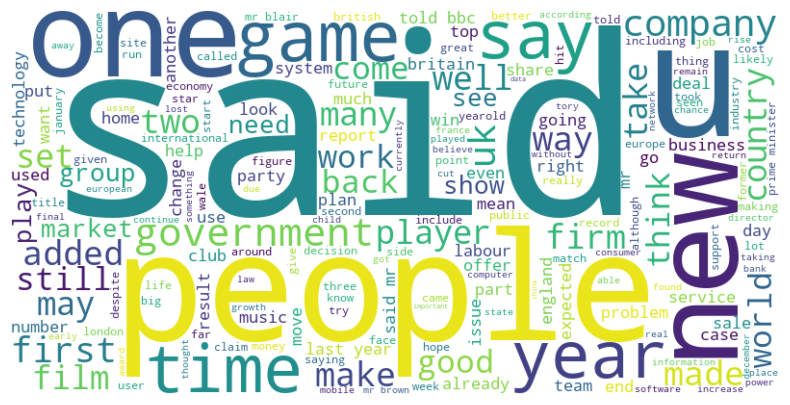

In [107]:
## Plot word cloud lemmatizado
plot_word_cloud(processed_text_lemmatize)

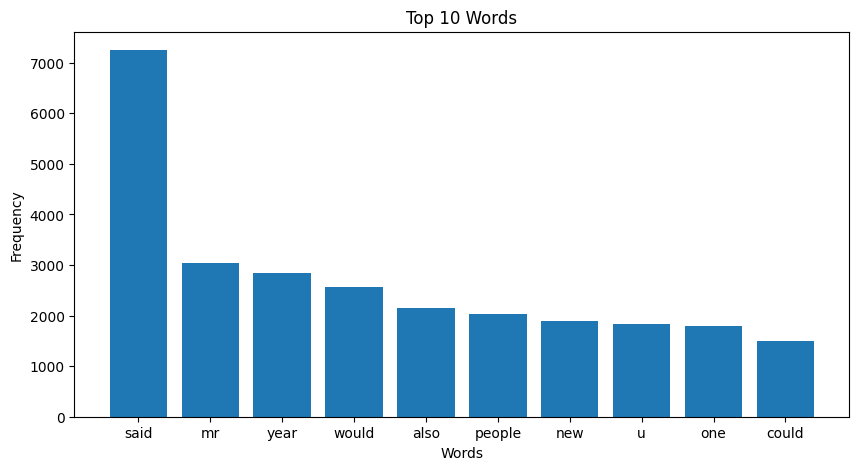

In [108]:
## Plot frequencia lemmatizado
plot_bar_frequencia(processed_text_lemmatize)

### Vetorização

In [109]:
X = {
    'tfidf': vetorizer_tfidf(processed_text_lemmatize),
    'bow': vetorizer_bow(processed_text_lemmatize),
    'bow_ngram': vetorizer_bow_ngrams(processed_text_lemmatize, 2, 2),
    'w2v': vetorizer_word2vec(processed_text_lemmatize)
}

#### Implementação da busca por similaridade

##### TF-IDF / BoW

Query: 'stock market crash'

1. Similaridade: 0.2387 | Categoria: business
   Excerto:  The market, former British government minister Michael Heseltine once said, has no morality.  And indeed, stock exchange traders around Asia have was...

2. Similaridade: 0.1929 | Categoria: business
   Excerto:  Standard Life, Europe's largest mutual life insurer, has cut bonuses for with-profit policyholders.  Annual bonus rates on its with-profits life poli...

3. Similaridade: 0.1682 | Categoria: business
   Excerto:  Life insurer Axa Sun Life has lowered annual bonus payouts for up to 50,000 with-profits investors.  Regular annual bonus rates on former Axa Equity ...

4. Similaridade: 0.1588 | Categoria: business
   Excerto:  Pan-European stock market Euronext has approached the London Stock Exchange (LSE) about a possible takeover bid.  "The approach is at an early stage ...

5. Similaridade: 0.1577 | Categoria: sport
   Excerto:  Greek sprinter Kostas Kenteris has denied claims that he faked 

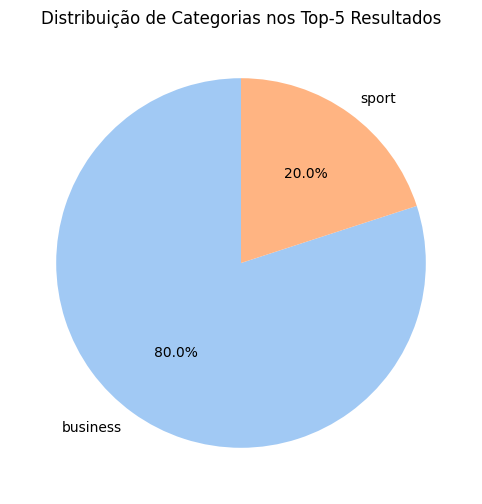

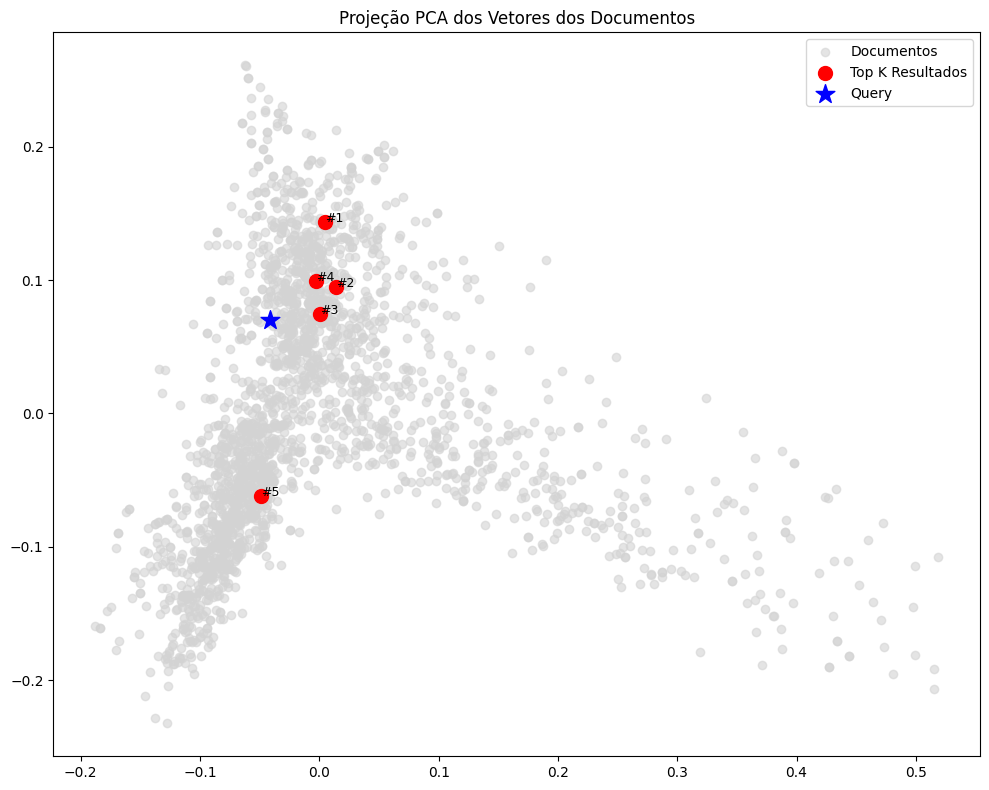

In [110]:
#TF-IDF
tfidf_query_proc,tfidf_q_vec,tfidf_scores,tfidf_indices = buscar("stock market crash", TfidfVectorizer().fit(processed_text_lemmatize), X['tfidf'], y, texts)
plot_category_distribution(y,tfidf_indices)
plot_pca_projection(X['tfidf'].toarray(), tfidf_indices, query_vec=tfidf_q_vec.toarray(), top_k=5)


Query: 'movie award'

1. Similaridade: 0.3832 | Categoria: tech
   Excerto:  PC first person shooter Half-Life 2 has won six Bafta Awards, including best game and best online game.  The title, developed by Valve, was released ...

2. Similaridade: 0.3626 | Categoria: entertainment
   Excerto:  Coronation Street has become the first soap to triumph at the South Bank Show Awards, which traditionally reward highbrow and groundbreaking culture....

3. Similaridade: 0.3231 | Categoria: entertainment
   Excerto:  Michael Moore's anti-Bush documentary Fahrenheit 9/11 has won best film at the US People's Choice Awards, voted for by the US public.  Mel Gibson's T...

4. Similaridade: 0.3218 | Categoria: tech
   Excerto:  The US movie industry has launched legal action to sue people who facilitate illegal film downloading.  The Motion Picture Association of America wan...

5. Similaridade: 0.3175 | Categoria: entertainment
   Excerto:  US actor Jamie Foxx has been given two nominations for Golde

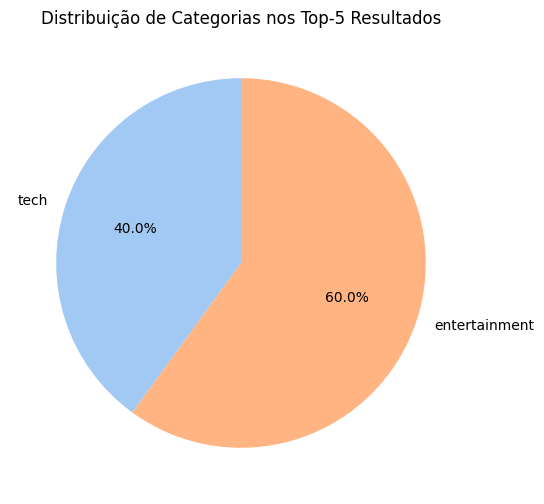

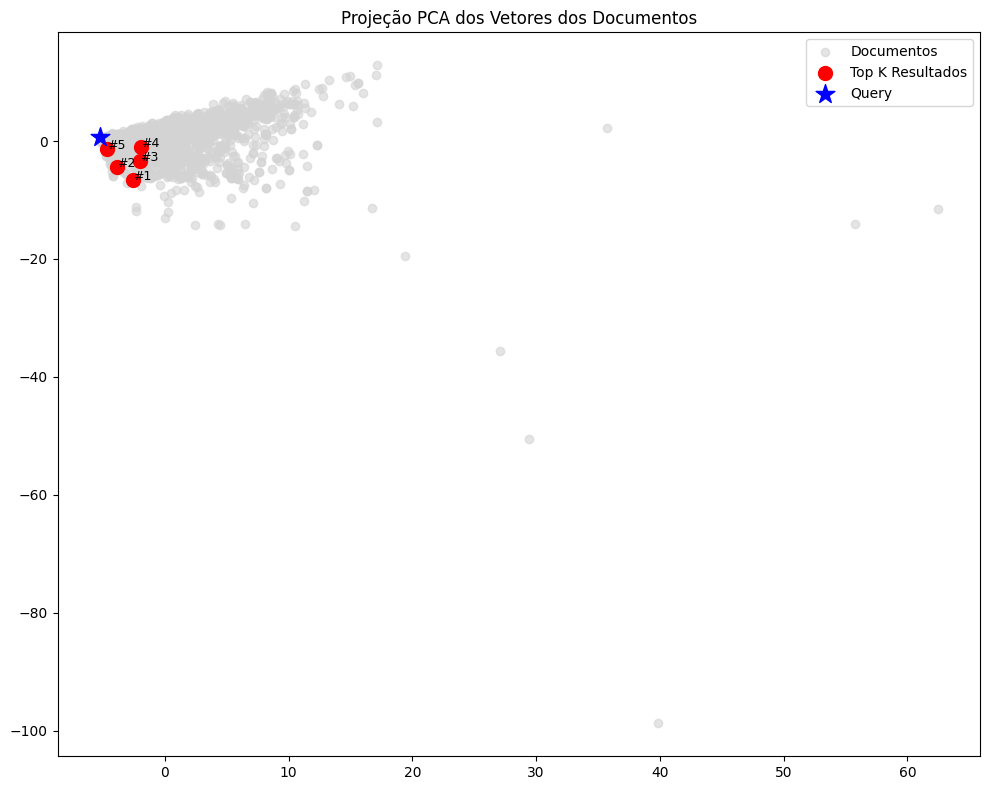

In [111]:
bow_query_proc,bow_q_vec,bow_scores,bow_indices = buscar("movie award", CountVectorizer().fit(processed_text_lemmatize), X['bow'], y, texts)
plot_category_distribution(y,bow_indices)
plot_pca_projection(X['bow'].toarray(), bow_indices, query_vec=bow_q_vec.toarray(), top_k=5)

Query: 'movie award'

1. Similaridade: 0.0591 | Categoria: entertainment
   Excerto:  British hopes of winning major Oscars were dashed as UK stars failed to win acting and directing prizes.  Despite three nominations, Mike Leigh's Ver...

2. Similaridade: 0.0000 | Categoria: business
   Excerto:  Parmalat, the Italian food group at the centre of one of Europe's most painful corporate scandals, has reported a doubling in profit.  Its pre-tax ea...

3. Similaridade: 0.0000 | Categoria: business
   Excerto:  Irish shares have risen to a record high, with investors persuaded to buy into the market by low inflation and strong growth forecasts.  The ISEQ ind...

4. Similaridade: 0.0000 | Categoria: business
   Excerto:  The soaring cost of oil has hit global economic growth, although world's major economies should weather the storm of price rises, according to the OE...

5. Similaridade: 0.0000 | Categoria: business
   Excerto:  Venezuelan authorities have said they will seize land owned by

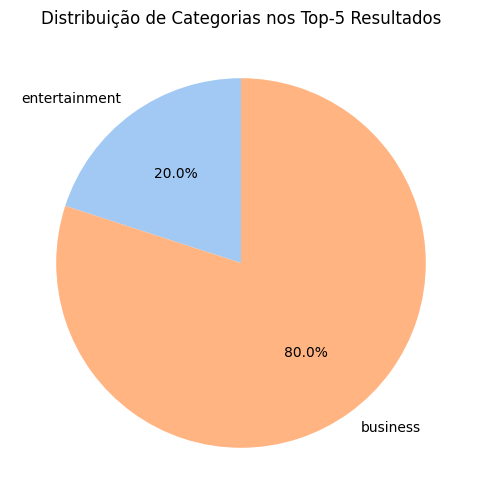

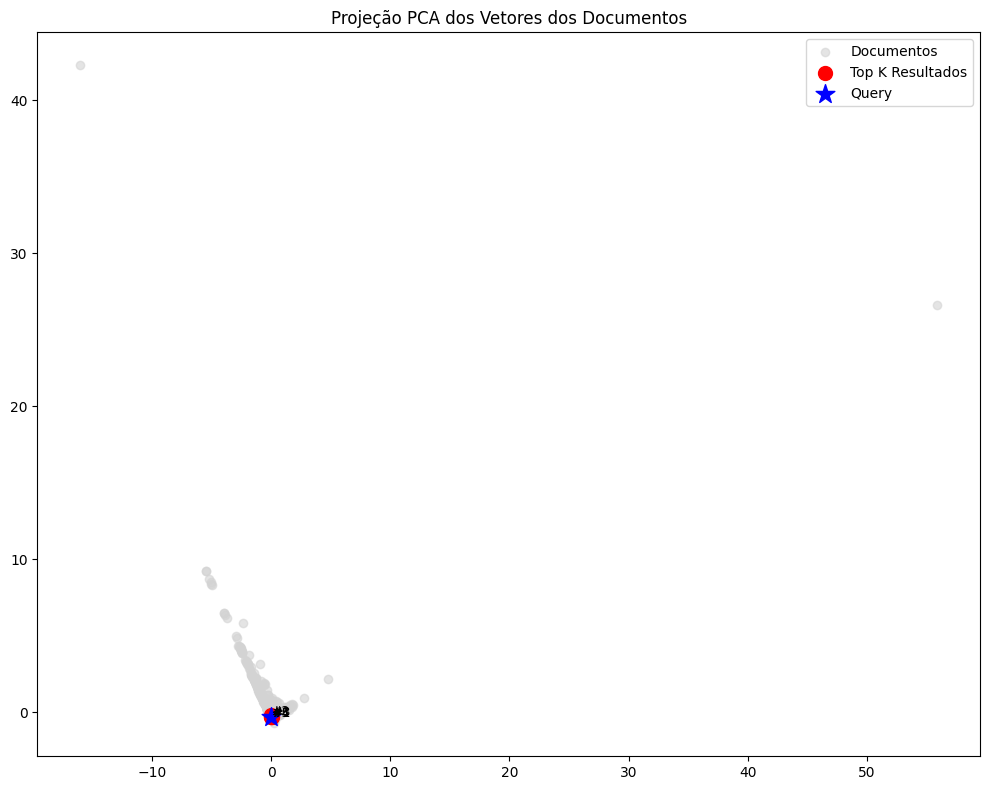

In [112]:
bowngram_query_proc,bowngram_q_vec,bowngram_scores,bowngram_indices = buscar("movie award", CountVectorizer(ngram_range=(2,2)).fit(processed_text_lemmatize), X['bow_ngram'], y, texts)
plot_category_distribution(y,bowngram_indices)
plot_pca_projection(X['bow_ngram'].toarray(), bowngram_indices, query_vec=bowngram_q_vec.toarray(), top_k=5)

##### Word2Vec

In [113]:
w2v_query_proc,w2v_q_vec,w2v_scores,w2v_indices = buscar_w2v("computer", Word2Vec(processed_text_lemmatize,vector_size=5, window=2, min_count=1), X['w2v'], y, texts)

Query: 'computer'

1. Similaridade: 0.0000 | Categoria: tech
   Excerto:  Online role playing games are time-consuming, but enthralling flights from reality. But are some people taking their fantasy lives too seriously?  Wh...

2. Similaridade: 0.0000 | Categoria: tech
   Excerto:  The man making sure US computer networks are safe and secure has resigned after only a year in his post.  Amit Yoran was director of the National Cyb...

3. Similaridade: 0.0000 | Categoria: tech
   Excerto:  A new European directive could put software writers at risk of legal action, warns former programmer and technology analyst Bill Thompson.  If it get...

4. Similaridade: 0.0000 | Categoria: tech
   Excerto:  Computer users across the world continue to ignore security warnings about spam e-mails and are being lured into buying goods, a report suggests.  Mo...

5. Similaridade: 0.0000 | Categoria: tech
   Excerto:  BT is introducing two initiatives to help beat rogue dialler scams, which can cost dial-up

### Data Split

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X['tfidf'], y, 
    test_size=0.2, 
    random_state=SEED,
    stratify=y  # Maintain class distribution
)

print(f"Treino: {X_train.shape[0]} samples")
print(f"Teste: {X_test.shape[0]} samples")
print(f"\nDistribuição de classes - Treino:\n{pd.Series(y_train).value_counts()}")
print(f"\Distribuição de classes - Teste:\n{pd.Series(y_test).value_counts()}")

Treino: 1780 samples
Teste: 445 samples

Distribuição de classes - Treino:
sport            409
business         408
politics         333
tech             321
entertainment    309
Name: count, dtype: int64
\Distribuição de classes - Teste:
business         102
sport            102
politics          84
tech              80
entertainment     77
Name: count, dtype: int64


### Treinamento

In [115]:
svm_model = SVC(
    kernel='linear',  
    C=1.0,           
    random_state=SEED,
    probability=True
)

print("Training SVM classifier...")
svm_model.fit(X_train, y_train)
print("Training completed!")

Training SVM classifier...
Training completed!


In [116]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)  # Probability scores for each class

print("First 10 predictions vs actual labels:")
for i in range(10):
    print(f"Predicted: {y_pred[i]:15} | Actual: {y_test[i]:15}")

First 10 predictions vs actual labels:
Predicted: business        | Actual: business       
Predicted: business        | Actual: business       
Predicted: entertainment   | Actual: entertainment  
Predicted: business        | Actual: business       
Predicted: business        | Actual: business       
Predicted: sport           | Actual: sport          
Predicted: politics        | Actual: politics       
Predicted: politics        | Actual: politics       
Predicted: sport           | Actual: sport          
Predicted: politics        | Actual: politics       


### Métricas e validações

MODEL PERFORMANCE METRICS
Accuracy:  0.9865 (98.65%)
Precision: 0.9867 (98.67%)
Recall:    0.9865 (98.65%)
F1-Score:  0.9865 (98.65%)

CLASSIFICATION REPORT:
------------------------------------------------------------
               precision    recall  f1-score   support

     business       1.00      0.96      0.98       102
entertainment       0.97      1.00      0.99        77
     politics       0.99      0.98      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445


CONFUSION MATRIX:
------------------------------------------------------------
[[ 98   1   1   1   1]
 [  0  77   0   0   0]
 [  0   1  82   0   1]
 [  0   0   0 102   0]
 [  0   0   0   0  80]]


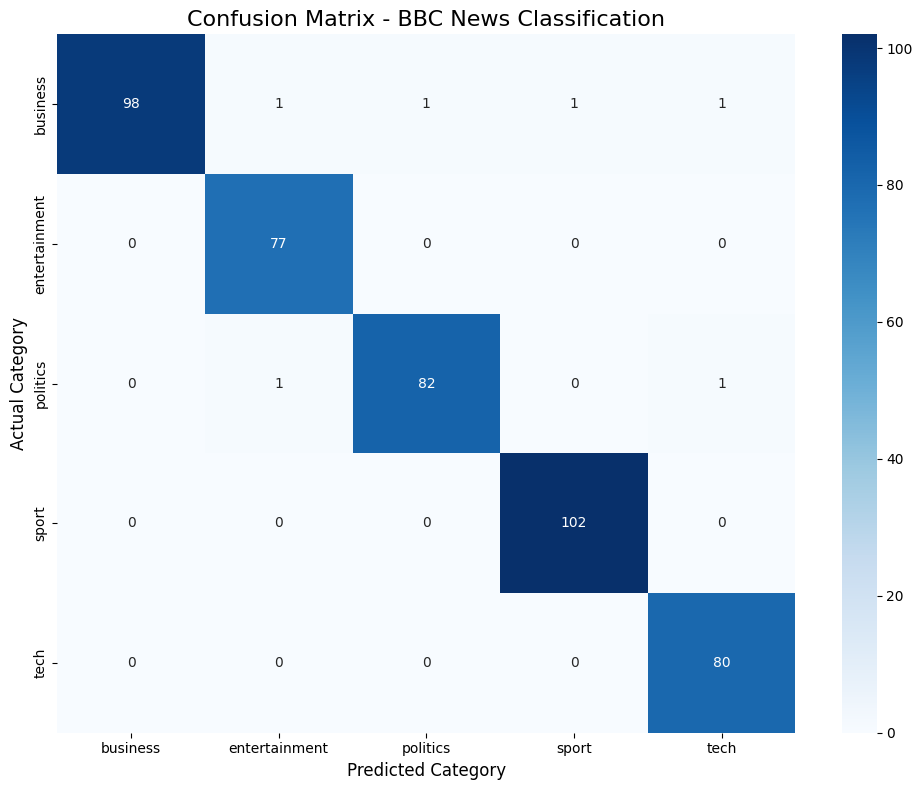


PER-CLASS PERFORMANCE:
------------------------------------------------------------
business        - Precision: 1.0000, Recall: 0.9608, F1: 0.9800
entertainment   - Precision: 0.9747, Recall: 1.0000, F1: 0.9872
politics        - Precision: 0.9880, Recall: 0.9762, F1: 0.9820
sport           - Precision: 0.9903, Recall: 1.0000, F1: 0.9951
tech            - Precision: 0.9756, Recall: 1.0000, F1: 0.9877


In [117]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("="*60)

# Detailed classification report
print("\nCLASSIFICATION REPORT:")
print("-"*60)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nCONFUSION MATRIX:")
print("-"*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(y)), 
            yticklabels=sorted(set(y)))
plt.title('Confusion Matrix - BBC News Classification', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class metrics
print("\nPER-CLASS PERFORMANCE:")
print("-"*60)
unique_classes = sorted(set(y))
for class_name in unique_classes:
    class_precision = precision_score(y_test, y_pred, labels=[class_name], average='weighted')
    class_recall = recall_score(y_test, y_pred, labels=[class_name], average='weighted')
    class_f1 = f1_score(y_test, y_pred, labels=[class_name], average='weighted')
    print(f"{class_name:15} - Precision: {class_precision:.4f}, Recall: {class_recall:.4f}, F1: {class_f1:.4f}")

### Validação do modelo

In [118]:
print("\n" + "="*60)
print("VALIDAÇÃO DO MODELO - RESUMO")
print("="*60)
print(f"✅ Data Split: {X_train.shape[0]} training, {X_test.shape[0]} test samples")
print(f"✅ SVM Classifier: Linear kernel with C={svm_model.C}")
print(f"✅ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Overall F1-Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"✅ Number of classes: {len(unique_classes)}")
print(f"✅ Vocabulary size: {X['tfidf'].shape[1]} features")
print(f"✅ Number of documents (total): {len(processed_texts)}")

# Verificação de overfitting
train_accuracy = svm_model.score(X_train, y_train)
test_accuracy = svm_model.score(X_test, y_test)
print(f"\n📊 Training accuracy: {train_accuracy:.4f}")
print(f"📊 Testing accuracy:  {test_accuracy:.4f}")


VALIDAÇÃO DO MODELO - RESUMO
✅ Data Split: 1780 training, 445 test samples
✅ SVM Classifier: Linear kernel with C=1.0
✅ Overall Accuracy: 0.9865 (98.65%)
✅ Overall F1-Score: 0.9865 (98.65%)
✅ Number of classes: 5
✅ Vocabulary size: 27767 features
✅ Number of documents (total): 2

📊 Training accuracy: 0.9994
📊 Testing accuracy:  0.9865
